輸入股票代號AAPL
開始時間，format = yyyy-mm-dd2025-01-01
結束時間，format = yyyy-mm-dd2025-12-31


/tmp/ipython-input-72715857.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(target, start = start_time, end = end_time)
[*********************100%***********************]  1 of 1 completed


Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2025-01-02  242.752106  247.978468  240.731247  247.809220  55740700
2025-01-03  242.264297  243.080598  240.800915  242.264297  40244100
2025-01-06  243.896927  246.216438  242.105028  243.210031  45045600
2025-01-07  241.119492  244.444450  240.263363  241.886014  40856000
2025-01-08  241.607269  242.612732  238.969207  240.830782  37628900
...                ...         ...         ...         ...       ...
2025-12-23  272.359985  272.500000  269.559998  270.839996  29642000
2025-12-24  273.809998  275.429993  272.200012  272.339996  17910600
2025-12-26  273.399994  275.369995  272.859985  274.160004  21521800
2025-12-29  273.760010  274.359985  272.350006  272.690002  23715200
2025-12-30  273.079987  274.079987  272.279999  272.809998  22139600

[249 rows x 5 columns]
Price     

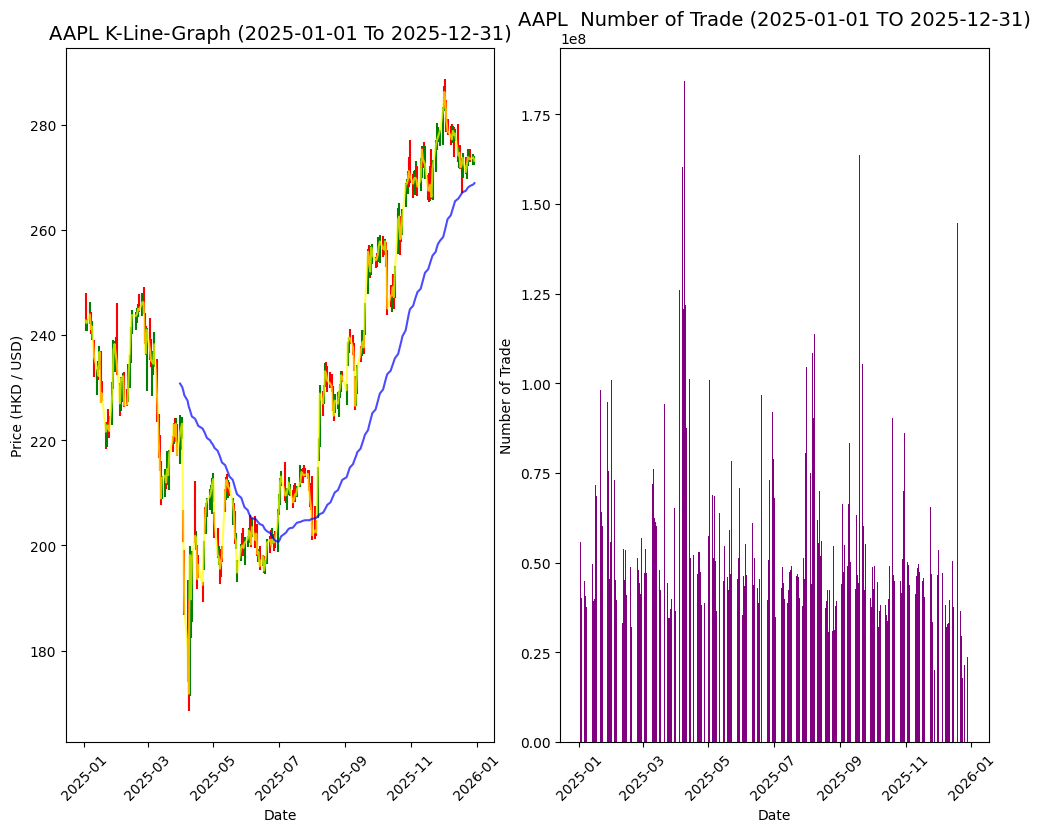

In [16]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

target = input('輸入股票代號')
start_time = input('開始時間，format = yyyy-mm-dd')
end_time = input('結束時間，format = yyyy-mm-dd')
# Specific calendar year
data = yf.download(target, start = start_time, end = end_time)
print(data)
if data.empty:
    print(f"無法下載 {target} 的資料，請檢查代號或日期是否正確")
else:
    print(data.tail(10))  # 顯示最後10筆，確認資料OK
date = data.index
# More information of that 股票代號
ticker = yf.Ticker('AAPL')
#print(ticker.info)
Closing_data = data["Close"].to_numpy()
last_data = (len(data)-1)
Open_data = data["Open"].to_numpy()
Highest = data["High"].to_numpy()
Lowest = data["Low"].to_numpy()
no_of_trade = data["Volume"].to_numpy()
#簡單移動平均線 SMA（n日） = (過去 n 天的收盤價總和) ÷ n
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_60'] = data['Close'].rolling(window=60).mean()
print("簡單移動平均線(20日):",data['SMA_20'])
SMA_data_20 = data['SMA_20'].to_numpy()
SMA_data_60 = data['SMA_60'].to_numpy()
#收益率標準差
returns = data["Close"].pct_change().dropna() # 每日收益率
std_dev_daily = returns.std() # 日標準差
std_dev_annual = std_dev_daily * np.sqrt(252) # 年化標準差
print("收益率標準差:",std_dev_annual )

#K線圖
fig,ax = plt.subplots(1,2,figsize = (10,8))
for i in range(len(Closing_data)):
  if (Open_data[i]- Closing_data[i]) >0:
    bottom_data = Closing_data[i]
    colour = "red"
  else:
    colour = "green"
    bottom_data = Open_data[i]
  ax[0].bar(date[i],abs(Open_data[i]- Closing_data[i]),bottom = bottom_data,width = 0.5,color = colour)
  #plt.bar(date[i],abs(Highest[i]- Lowest[i]),bottom = Lowest[i],width = 0.1,color = colour)
  ax[0].vlines(date[i], Lowest[i], Highest[i],color=colour, linewidth=1.5)
  ax[1].bar(date[i],no_of_trade[i],color = 'purple')

ax[0].plot(date,Closing_data,color = "yellow",alpha = 0.7 ) # 在迴圈外畫完整的收市價線（黃色）
ax[0].plot(date, SMA_data_60,color= "blue",alpha = 0.7 )#MA 線
ax[0].tick_params(axis='x', rotation=45) #調整 x 軸刻度標籤（x-tick labels）的旋轉角度 plt.xticks(rotation=45)
ax[1].tick_params(axis='x', rotation=45)
fig.tight_layout() #自動調整圖表（figure）的佈局 plt.tight_layout()
fig.show()
# 美化圖表
ax[0].set_title(f"{target} K-Line-Graph ({start_time} To {end_time})", fontsize=14)
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Price (HKD / USD)")
ax[1].set_title(f"{target}  Number of Trade ({start_time} TO {end_time})", fontsize=14)
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Number of Trade")
#文字報告（print 或 txt 檔）：最近價格 vs 60 日平均（漲/跌 %）、最近 1 月波動度 vs 過去一年平均





